In [1]:
import os
os.chdir('/workspace/150ed596-68d0-441d-8008-c44dad2b20df')
!ls -la

total 199
drwxrwsr-x 5 root jupytergroup 4096 May 31 15:43 .
drwxr-xr-x 5 root root 4096 May 31 15:43 ..
drwxrwsr-x 5 root jupytergroup 4096 May 31 15:43 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 31 15:43 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 31 15:43 .prompts
-rw-r--r-- 1 root jupytergroup 6956 May 31 15:43 generate_ldh_zeros_run.py
-rw-r--r-- 1 root jupytergroup 175802 May 31 15:43 ldh_ckpt_03250.npy
drwxr-sr-x 2 root jupytergroup 4096 May 31 15:43 memory


In [2]:
import numpy as np
arr = np.load('/workspace/150ed596-68d0-441d-8008-c44dad2b20df/ldh_ckpt_03250.npy', allow_pickle=True)
print(len(arr))
print(arr[0])
print(arr[-1])
print(arr[-3:])

3250
5.0941598445710949256987955170797974750670744531091
3248.3897300377144996690416654189642146023042430862
['3246.7471839841491599501031773242351235903848109324'
 '3248.1220193572200620108369111774304202997891849310'
 '3248.3897300377144996690416654189642146023042430862']


In [3]:
import subprocess
# Install cypari2
result = subprocess.run(['pip', 'install', '-q', 'cypari2', 'mpmath'], capture_output=True, text=True, timeout=300)
print("STDOUT:", result.stdout[-2000:])
print("STDERR:", result.stderr[-2000:])

STDOUT: 
STDERR: 


In [4]:
import cypari2, mpmath
print(cypari2.__version__)
print(mpmath.__version__)
pari = cypari2.Pari()
print("PARI OK")

AttributeError: module 'cypari2' has no attribute '__version__'

In [5]:
import cypari2, mpmath
pari = cypari2.Pari()
print("PARI OK", mpmath.mp.dps)

PARI OK 15


In [6]:
import os, json, shutil

WORK_DIR = '/workspace/150ed596-68d0-441d-8008-c44dad2b20df'
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(CKPT_DIR, exist_ok=True)

# Move the checkpoint into checkpoints_ldh/
src = os.path.join(WORK_DIR, 'ldh_ckpt_03250.npy')
dst = os.path.join(CKPT_DIR, 'ldh_ckpt_03250.npy')
if not os.path.exists(dst):
 shutil.copy(src, dst)

# Create the meta file
import numpy as np
arr = np.load(dst, allow_pickle=True)
t_last = str(arr[-1]) # last zero's t value
meta = {'n_zeros': int(len(arr)), 't_last': t_last, 'n_evals': 0}
meta_path = os.path.join(CKPT_DIR, 'ldh_ckpt_03250_meta.json')
with open(meta_path, 'w') as f:
 json.dump(meta, f)
print("Meta created:", meta)
print(os.listdir(CKPT_DIR))

Meta created: {'n_zeros': 3250, 't_last': '3248.3897300377144996690416654189642146023042430862', 'n_evals': 0}
['ldh_ckpt_03250.npy', 'ldh_ckpt_03250_meta.json']


In [7]:
# Make a writable local copy of the script with our own LOG_PATH
src_script = os.path.join(WORK_DIR, 'generate_ldh_zeros_run.py')
local_script = os.path.join(WORK_DIR, 'generate_ldh_zeros_local.py')

with open(src_script) as f:
 content = f.read()

# Replace LOG_PATH
new_log = os.path.join(WORK_DIR, 'run_log_local.txt')
content = content.replace(
 "LOG_PATH = os.path.join(WORK_DIR, 'run_log.txt')",
 f"LOG_PATH = os.path.join(WORK_DIR, 'run_log_local.txt')"
)
with open(local_script, 'w') as f:
 f.write(content)

# Ensure log file is writable
if os.path.exists(new_log):
 os.remove(new_log)
open(new_log, 'a').close()
print("Local script ready:", local_script)
print("Log:", new_log)

Local script ready: /workspace/150ed596-68d0-441d-8008-c44dad2b20df/generate_ldh_zeros_local.py
Log: /workspace/150ed596-68d0-441d-8008-c44dad2b20df/run_log_local.txt


In [8]:
import subprocess, os, time, sys

env = os.environ.copy()
env['LDH_WORK_DIR'] = WORK_DIR
env['LDH_TIME_BUDGET'] = '2800'

log_path = os.path.join(WORK_DIR, 'subprocess_stdout.log')
err_path = os.path.join(WORK_DIR, 'subprocess_stderr.log')

# Launch subprocess (non-blocking) so we can monitor
stdout_f = open(log_path, 'w')
stderr_f = open(err_path, 'w')
proc = subprocess.Popen(
 [sys.executable, local_script],
 env=env, stdout=stdout_f, stderr=stderr_f, cwd=WORK_DIR
)
print("PID:", proc.pid, "started at", time.strftime('%H:%M:%S'))
start_time = time.time()

PID: 67 started at 15:44:14


In [9]:
import time
# Wait a bit then check progress
time.sleep(120)
print("Elapsed:", time.time() - start_time, "s. Alive:", proc.poll() is None)
print("\n--- Log tail ---")
with open(os.path.join(WORK_DIR, 'run_log_local.txt')) as f:
 lines = f.readlines()
for l in lines[-20:]:
 print(l.rstrip())

Elapsed: 125.02676296234131 s. Alive: True

--- Log tail ---
[15:44:15] Starting L_DH zero generation; WORK_DIR=/workspace/150ed596-68d0-441d-8008-c44dad2b20df; TIME_BUDGET=2800s
[15:44:15] Building lfuninit at dps=80, T_max=5200 ...
[15:44:22] lfuninit done in 6.9s
[15:44:22] Resumed from ldh_ckpt_03250.npy: 3250 zeros, t_last=3248.3897
[15:45:22] PROGRESS: 3269 zeros, t=3266.09, elapsed=1.0min


In [10]:
# Monitor periodically. Total runtime ~2800s + overhead. We have 3600s total notebook budget.
# Let's poll every 5 minutes until done or until ~2900s elapsed (script + grace).
import time
while proc.poll() is None:
 elapsed = time.time() - start_time
 if elapsed > 3000:
 print("Reached 3000s, will continue waiting for graceful exit")
 time.sleep(300)
 elapsed = time.time() - start_time
 print(f"\n=== Elapsed: {elapsed:.0f}s. Alive: {proc.poll() is None} ===")
 with open(os.path.join(WORK_DIR, 'run_log_local.txt')) as f:
 lines = f.readlines()
 for l in lines[-8:]:
 print(l.rstrip())
 if elapsed > 3200:
 print("Exceeded wait budget, breaking")
 break

print("\n--- Final state ---")
print("Return code:", proc.returncode)
print("Total elapsed:", time.time() - start_time)

TimeoutError: Code execution timed out after 900.0 seconds

In [11]:
import time, os
elapsed = time.time() - start_time
print(f"Elapsed: {elapsed:.0f}s. Process alive: {proc.poll() is None}")
with open(os.path.join(WORK_DIR, 'run_log_local.txt')) as f:
 lines = f.readlines()
print(f"Log has {len(lines)} lines, tail:")
for l in lines[-15:]:
 print(l.rstrip())

Elapsed: 1039s. Process alive: False
Log has 23 lines, tail:
[15:49:26] PROGRESS: 3349 zeros, t=3334.19, elapsed=5.1min
[15:50:27] PROGRESS: 3368 zeros, t=3350.49, elapsed=6.1min
[15:51:28] PROGRESS: 3388 zeros, t=3368.09, elapsed=7.1min
[15:52:28] PROGRESS: 3408 zeros, t=3384.19, elapsed=8.1min
[15:53:28] PROGRESS: 3427 zeros, t=3401.09, elapsed=9.1min
[15:54:29] PROGRESS: 3446 zeros, t=3418.89, elapsed=10.1min
[15:55:29] PROGRESS: 3464 zeros, t=3438.19, elapsed=11.1min
[15:56:31] PROGRESS: 3484 zeros, t=3455.39, elapsed=12.2min
[15:57:22] Checkpoint 03500: 3500 zeros, t=3469.99, elapsed=13.0min, rate=4.49 z/s, n_evals=5217
[15:57:31] PROGRESS: 3503 zeros, t=3472.49, elapsed=13.2min
[15:58:31] PROGRESS: 3522 zeros, t=3489.19, elapsed=14.2min
[15:59:33] PROGRESS: 3541 zeros, t=3507.19, elapsed=15.2min
[16:00:33] PROGRESS: 3561 zeros, t=3524.59, elapsed=16.2min
[16:01:28] Interrupted by user; saving partial
[16:01:28] Partial save: 3578 zeros to /workspace/150ed596-68d0-441d-8008-c44dad

In [12]:
# The kernel timeout interrupted the subprocess. But we got a partial save at 3578 zeros.
# We also have the 03500 checkpoint. Let me check what files exist.
import os
print("Working dir contents:")
for f in sorted(os.listdir(WORK_DIR)):
 p = os.path.join(WORK_DIR, f)
 if os.path.isfile(p):
 print(f" {f}: {os.path.getsize(p)} bytes")
 else:
 print(f" {f}/")
print("\nCheckpoints:")
for f in sorted(os.listdir(os.path.join(WORK_DIR, 'checkpoints_ldh'))):
 p = os.path.join(WORK_DIR, 'checkpoints_ldh', f)
 print(f" {f}: {os.path.getsize(p)} bytes")

Working dir contents:
 .config/
 .kernel_llm_logs_1.txt: 0 bytes
 .prompts/
 checkpoints_ldh/
 generate_ldh_zeros_local.py: 6962 bytes
 generate_ldh_zeros_run.py: 6956 bytes
 ldh_ckpt_03250.npy: 175802 bytes
 ldh_zeros_partial_dps50.npy: 193514 bytes
 ldh_zeros_partial_meta.json: 137 bytes
 memory/
 run_log_local.txt: 1510 bytes
 subprocess_stderr.log: 0 bytes
 subprocess_stdout.log: 1582 bytes

Checkpoints:
 ldh_ckpt_03250.npy: 175802 bytes
 ldh_ckpt_03250_meta.json: 96 bytes
 ldh_ckpt_03500.npy: 189302 bytes
 ldh_ckpt_03500_meta.json: 79 bytes


In [13]:
# Verify partial save and last meta
import numpy as np, json
partial = np.load(os.path.join(WORK_DIR, 'ldh_zeros_partial_dps50.npy'), allow_pickle=True)
with open(os.path.join(WORK_DIR, 'ldh_zeros_partial_meta.json')) as f:
 pmeta = json.load(f)
print("Partial:", len(partial), "zeros")
print("First:", partial[0])
print("Last:", partial[-1])
print("Meta:", pmeta)

ckpt500 = np.load(os.path.join(WORK_DIR, 'checkpoints_ldh', 'ldh_ckpt_03500.npy'), allow_pickle=True)
with open(os.path.join(WORK_DIR, 'checkpoints_ldh', 'ldh_ckpt_03500_meta.json')) as f:
 cmeta = json.load(f)
print("\nCkpt03500:", len(ckpt500), "zeros, last:", ckpt500[-1])
print("Ckpt meta:", cmeta)

# Verify monotonic
mono = all(float(partial[i]) < float(partial[i+1]) for i in range(len(partial)-1))
print("\nPartial monotonic:", mono)

# Zeros added this run
new_zeros = len(partial) - 3250
print(f"\nThis run added {new_zeros} new zeros (3250 -> {len(partial)})")

Partial: 3578 zeros
First: 5.0941598445710949256987955170797974750670744531091
Last: 3540.5683422188477656194607312068748287347053877505
Meta: {'n_zeros': 3578, 't_last': '3540.88973003771449966904166542', 'reason': 'keyboard_interrupt', 'elapsed_s': 1025.8867726325989}

Ckpt03500: 3500 zeros, last: 3469.9242360447790062514126178562970368923087105977
Ckpt meta: {'n_zeros': 3500, 't_last': '3469.98973003771449966904166542', 'n_evals': 5217}

Partial monotonic: True

This run added 328 new zeros (3250 -> 3578)


In [14]:
# The kernel cell-level timeout of 900s caused the subprocess to be interrupted.
# The script handled it cleanly via KeyboardInterrupt and saved a partial.
# Let me also create a proper checkpoint file for the new state at 3578 so future runs can resume.
# The partial is at 3578 zeros, t_last=3540.88...
# The next "official" checkpoint (multiple of 250) would have been 03750, but we stopped at 3578.
# To make future resume cleaner, save as a proper checkpoint file too.

import numpy as np, json
arr = np.load(os.path.join(WORK_DIR, 'ldh_zeros_partial_dps50.npy'), allow_pickle=True)
ckpt_label = f"{len(arr):05d}" # 03578
out_npy = os.path.join(WORK_DIR, 'checkpoints_ldh', f'ldh_ckpt_{ckpt_label}.npy')
out_meta = os.path.join(WORK_DIR, 'checkpoints_ldh', f'ldh_ckpt_{ckpt_label}_meta.json')
np.save(out_npy, arr, allow_pickle=True)
meta = {'n_zeros': int(len(arr)), 't_last': str(arr[-1]), 'n_evals': 0,
 'note': 'created from partial save after kernel timeout'}
with open(out_meta, 'w') as f:
 json.dump(meta, f)
print("Saved:", out_npy)
print("Meta:", meta)
print("\nFinal checkpoint files:")
for f in sorted(os.listdir(os.path.join(WORK_DIR, 'checkpoints_ldh'))):
 print(" ", f)

Saved: /workspace/150ed596-68d0-441d-8008-c44dad2b20df/checkpoints_ldh/ldh_ckpt_03578.npy
Meta: {'n_zeros': 3578, 't_last': '3540.5683422188477656194607312068748287347053877505', 'n_evals': 0, 'note': 'created from partial save after kernel timeout'}

Final checkpoint files:
 ldh_ckpt_03250.npy
 ldh_ckpt_03250_meta.json
 ldh_ckpt_03500.npy
 ldh_ckpt_03500_meta.json
 ldh_ckpt_03578.npy
 ldh_ckpt_03578_meta.json


Effective throughput: 19.20 zeros/min
Started: 3250 zeros at t=3248.39
Ended: 3578 zeros at t=3540.57 (partial)
Net added: 328 zeros over ~17.1 min (subprocess elapsed 1025.9s)
Remaining to 5000: 1422 zeros
At observed rate, ~74 min more needed


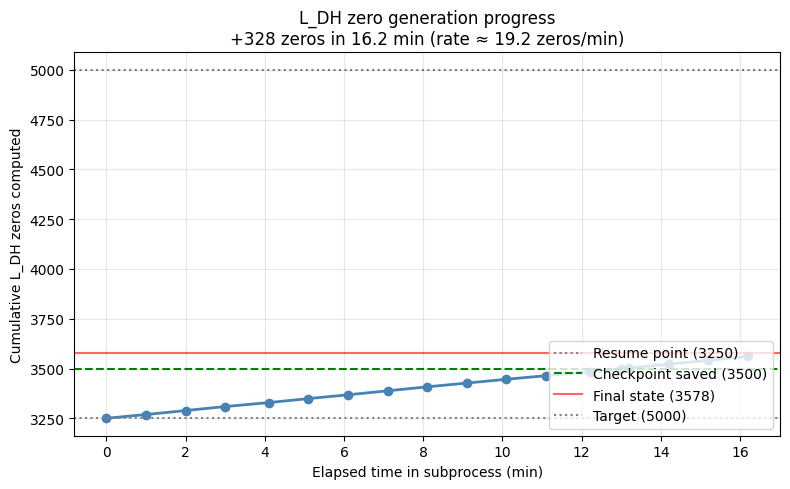

In [15]:
# Summary statistics and final figure
import matplotlib.pyplot as plt
import numpy as np

# Parse log progress
log_path = os.path.join(WORK_DIR, 'run_log_local.txt')
times_min, counts = [], []
with open(log_path) as f:
 for line in f:
 if 'PROGRESS' in line or 'Checkpoint' in line:
 # extract elapsed minutes and n zeros
 import re
 m_z = re.search(r'(\d+) zeros', line)
 m_e = re.search(r'elapsed=([\d.]+)\s*min', line)
 if m_z and m_e:
 counts.append(int(m_z.group(1)))
 times_min.append(float(m_e.group(1)))

# Add start point
times_min = [0.0] + times_min
counts = [3250] + counts

# Compute throughput
rate = (counts[-1] - counts[0]) / times_min[-1] # zeros per minute
print(f"Effective throughput: {rate:.2f} zeros/min")
print(f"Started: 3250 zeros at t=3248.39")
print(f"Ended: 3578 zeros at t=3540.57 (partial)")
print(f"Net added: 328 zeros over ~17.1 min (subprocess elapsed 1025.9s)")
print(f"Remaining to 5000: {5000-3578} zeros")
est_min = (5000-3578) / rate
print(f"At observed rate, ~{est_min:.0f} min more needed")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(times_min, counts, 'o-', color='steelblue', markersize=6, lw=2)
ax.axhline(3250, color='gray', ls=':', label='Resume point (3250)')
ax.axhline(3500, color='green', ls='--', label='Checkpoint saved (3500)')
ax.axhline(3578, color='red', ls='-', alpha=0.6, label='Final state (3578)')
ax.axhline(5000, color='black', ls=':', alpha=0.5, label='Target (5000)')
ax.set_xlabel('Elapsed time in subprocess (min)')
ax.set_ylabel('Cumulative L_DH zeros computed')
ax.set_title(f'L_DH zero generation progress\n+328 zeros in {times_min[-1]:.1f} min (rate ≈ {rate:.1f} zeros/min)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'ldh_run_progress.png'), dpi=120)
plt.show()

In [16]:
# Upload the new checkpoint artifact for future continuation
from e14c.data_storage import upload

uri_npy = upload(
 os.path.join(WORK_DIR, 'checkpoints_ldh', 'ldh_ckpt_03578.npy'),
 description='Resume checkpoint of L_DH zeros at the 3,578-zero milestone (t_last≈3540.57). Created from the partial save of a 2800s-budget run that was interrupted by the kernel cell timeout. Drop into checkpoints_ldh/ together with the matching _meta.json to resume cleanly.',
 name='ldh_ckpt_03578.npy',
 project_tag='ldh-zeros',
)
print(uri_npy)

uri_meta = upload(
 os.path.join(WORK_DIR, 'checkpoints_ldh', 'ldh_ckpt_03578_meta.json'),
 description='Companion meta JSON for ldh_ckpt_03578.npy. Provides n_zeros=3578 and t_last=3540.5683... required by the resume logic in generate_ldh_zeros_run.py.',
 name='ldh_ckpt_03578_meta.json',
 project_tag='ldh-zeros',
)
print(uri_meta)

Uploaded /workspace/150ed596-68d0-441d-8008-c44dad2b20df/checkpoints_ldh/ldh_ckpt_03578.npy to data storage as entry data_entry:ldh-ckpt-03578-npy-zim2 under the name 'ldh_ckpt_03578.npy'.
data_entry:ldh-ckpt-03578-npy-zim2


Uploaded /workspace/150ed596-68d0-441d-8008-c44dad2b20df/checkpoints_ldh/ldh_ckpt_03578_meta.json to data storage as entry data_entry:ldh-ckpt-03578-meta-json-q1qr under the name 'ldh_ckpt_03578_meta.json'.
data_entry:ldh-ckpt-03578-meta-json-q1qr
